In [3]:
import numpy as np

# generate sample dataset
rng = np.random.default_rng(seed=42)
x = 2 * rng.random((100, 1))
y = 4 + 3 * x + rng.standard_normal((100, 1))

## Batch Gradient Descent

In [4]:
def batch_GD(x, y, iterations=1000, learning_rate=0.1):
    m = len(x)
    x = np.c_[np.ones((m, 1)), x]
    theta = rng.random((x.shape[1], 1)) # generate random parameters first
    for i in range(iterations):
        gradients = 2/m * x.T @ (x @ theta - y) # get gradient vector of cost function (MSE)
        theta = theta - learning_rate * gradients # improve parameters
    
    return theta
    
batch_GD(x, y)

array([[3.94869973],
       [3.03831479]])

## Stochastic Gradient Descent

In [5]:
def stoch_GD(x, y, iterations=1000, t0=5, t1=50):
    def learning_schedule(t): # reduces learning rate at each epoch to improve results
        return t0 / (t + t1)

    m = len(x)
    x = np.c_[np.ones((m, 1)), x]
    theta = rng.random((x.shape[1], 1))

    for i in range(iterations):
        for j in range(m):
            random_idx = rng.integers(m) # get random instance
            xi = x[random_idx:random_idx+1]
            yi = y[random_idx:random_idx+1]
            gradients = 2 * xi.T @ (xi @ theta - yi) # get gradient vector of cost function
            learning_rate = learning_schedule(i * m + j) # apply learning schedule
            theta = theta - learning_rate * gradients # improve parameters
    
    return theta

stoch_GD(x, y)

array([[3.95948668],
       [3.03957581]])

## Learning curve

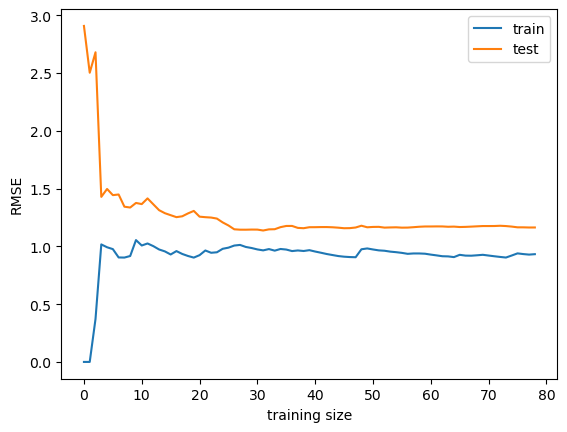

In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def learning_curve(model, x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
    train_errors, test_errors = [], []
    for m in range(1, len(x_train)): # get error for each sample size
        model.fit(x_train[:m], y_train[:m])
        y_train_predict = model.predict(x_train[:m])
        y_test_predict = model.predict(x_test)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        test_errors.append(mean_squared_error(y_test, y_test_predict))

    plt.plot(np.sqrt(train_errors), label='train')
    plt.plot(np.sqrt(test_errors), label='test')
    plt.xlabel('training size')
    plt.ylabel('RMSE')
    plt.legend()
    plt.show()

from sklearn.linear_model import LinearRegression
lg = LinearRegression()
learning_curve(lg, x, y)

#### The above regression model seems underfitted. Error is high and the gap between both curves is low.